# Automated Visual Triage System for Skin Conditions
## Foundations of Computer Vision (CSE 3176) - Mini Project

**Team Members:**
- Rajit Mohan Shrivastava (240962378)
- Prayatshu Misra (240962386)
- Eknoor Singh Chhabra (240962412)
**Branch:** AIML-B

This notebook demonstrates the complete computer vision pipeline for automated triage of skin conditions. It utilizes OpenCV and scikit-image for preprocessing, enhancement, segmentation, and feature extraction.

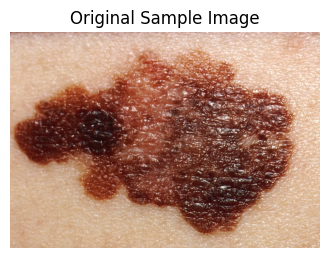

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern
import urllib.request
from PIL import Image

# Function to download a sample image if one is not provided locally
def get_sample_image():
    url = "https://upload.wikimedia.org/wikipedia/commons/6/6c/Melanoma.jpg"
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    response = urllib.request.urlopen(req)
    arr = np.asarray(bytearray(response.read()), dtype=np.uint8)
    img = cv2.imdecode(arr, -1)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

image = get_sample_image()
plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.title("Original Sample Image")
plt.axis("off")
plt.show()

### Phase 1: Preprocessing & Enhancement

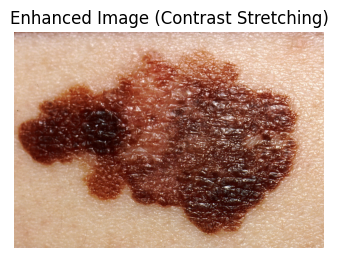

In [2]:
def apply_contrast_stretching(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    min_val, max_val = np.min(l), np.max(l)
    if max_val > min_val:
        stretched = ((l - min_val) / (max_val - min_val) * 255).astype(np.uint8)
    else:
        stretched = l
    return cv2.cvtColor(cv2.merge((stretched, a, b)), cv2.COLOR_LAB2RGB)

enhanced_img = apply_contrast_stretching(image)
plt.figure(figsize=(4, 4))
plt.imshow(enhanced_img)
plt.title("Enhanced Image (Contrast Stretching)")
plt.axis("off")
plt.show()

### Phase 2: Noise Reduction & Edge Detection

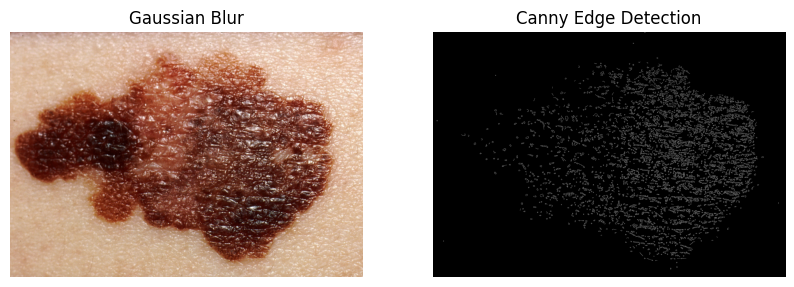

In [3]:
blurred_img = cv2.GaussianBlur(enhanced_img, (5, 5), 0)
gray_img = cv2.cvtColor(blurred_img, cv2.COLOR_RGB2GRAY)
edges_img = cv2.Canny(gray_img, 100, 200)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(blurred_img)
ax[0].set_title("Gaussian Blur")
ax[0].axis("off")
ax[1].imshow(edges_img, cmap="gray")
ax[1].set_title("Canny Edge Detection")
ax[1].axis("off")
plt.show()

### Phase 3: Isolation & Segmentation (K-Means)

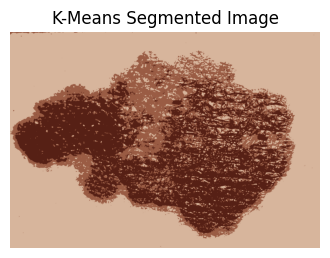

In [4]:
k = 3
pixel_values = np.float32(blurred_img.reshape((-1, 3)))
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
_, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
centers = np.uint8(centers)
segmented_img = centers[labels.flatten()].reshape(blurred_img.shape)

plt.figure(figsize=(4, 4))
plt.imshow(segmented_img)
plt.title("K-Means Segmented Image")
plt.axis("off")
plt.show()

### Phase 4: Feature Analysis (LBP)

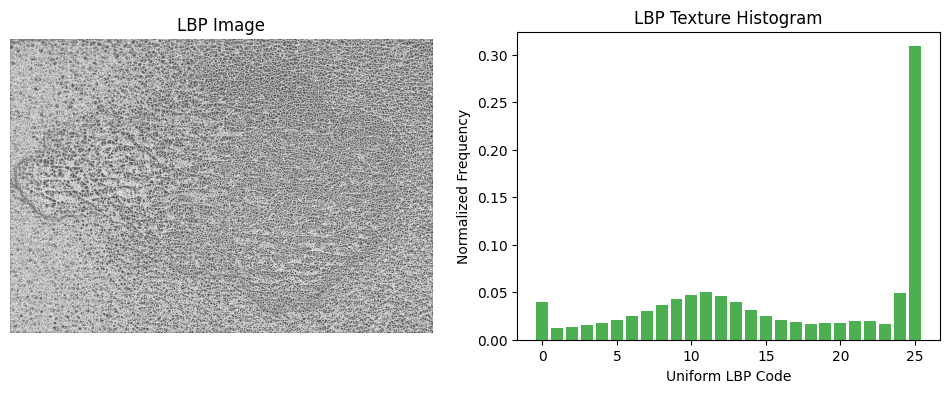

In [5]:
gray = cv2.cvtColor(enhanced_img, cv2.COLOR_RGB2GRAY)
radius, n_points = 3, 24
lbp = local_binary_pattern(gray, n_points, radius, method="uniform")
(hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
hist = hist.astype("float")
hist /= (hist.sum() + 1e-7)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(lbp, cmap="gray")
ax[0].set_title("LBP Image")
ax[0].axis("off")
ax[1].bar(np.arange(len(hist)), hist, color="#4CAF50")
ax[1].set_title("LBP Texture Histogram")
ax[1].set_xlabel("Uniform LBP Code")
ax[1].set_ylabel("Normalized Frequency")
plt.show()